torch.Size([1, 12, 288, 288]) torch.Size([1, 288, 288])
['SmaAT_UNet_rain_threshold_50_epoch=80-val_total_loss=0.181938.ckpt', 'SmaAT_UNet_VQ_MSE-num32-commit0.75_rain_threshold_50_epoch=74-val_total_loss=0.183429.ckpt', 'SmaAT_UNet_VQ_MSE-MixConv-downdownmixmix-mixupupup-best-0.0120-num32-commit0.75_rain_threshold_50_epoch=49-val_total_loss=0.217658.ckpt', 'SmaAT_UNet_MixConv_rain_threshold_50_epoch=77-val_total_loss=0.210975.ckpt']
Persistence 1053.890380859375
SmaAT-UNet 727.3772583007812
SQ-UNet 640.9107666015625
SMiQ-UNet 695.2352294921875
SMi-UNet 787.2345581054688


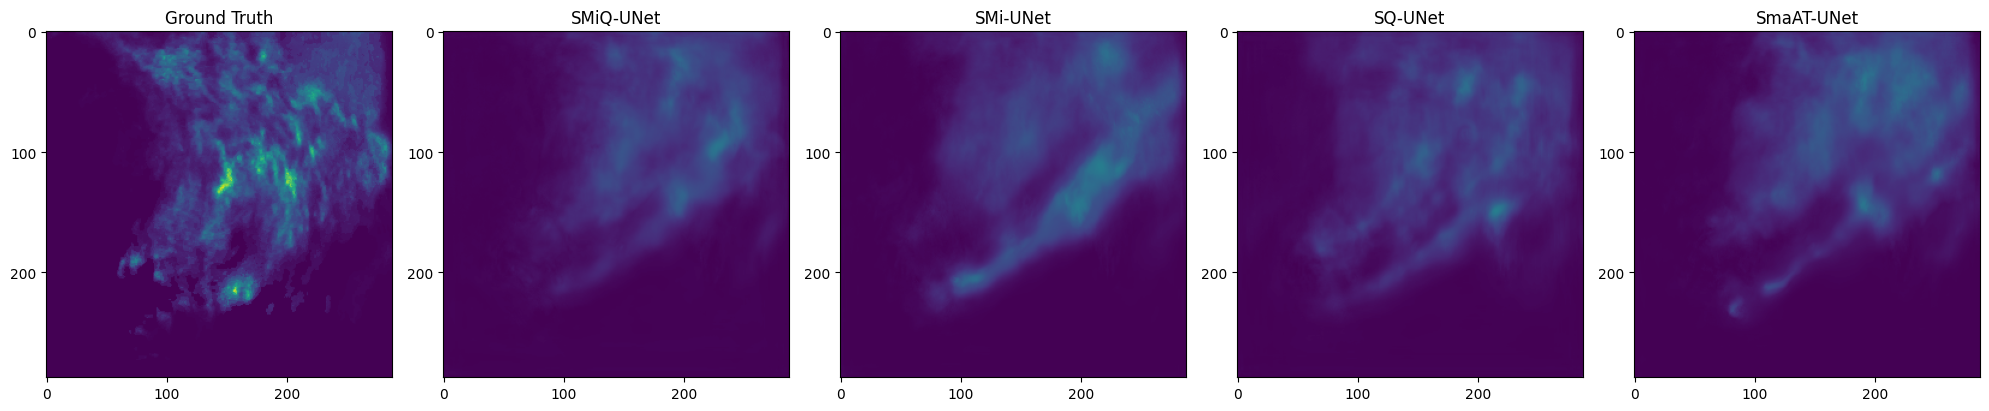

In [12]:
# Used to plot examples for ground truth, and model outputs for visualization purposes
# Needs polishing

import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import os
import models.unet_precip_regression_lightning as unet_regr
from models import SmaAT_UNet_VQ_lightning
from utils import dataset_precip
from argparse import Namespace

dataset = dataset_precip.precipitation_maps_oversampled_h5(
            in_file="data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5",
            num_input_images=12,
            num_output_images=6, train=False)

# 222, 444, 777, 1337 is fine
x, y_true = dataset[5]

# add batch dimension
x = torch.tensor(x).unsqueeze(0)
y_true = torch.tensor(y_true).unsqueeze(0)
print(x.shape, y_true.shape)

models_dir = "lightning/precip_regression/comparison"
precip_models = [m for m in os.listdir(models_dir) if ".ckpt" in m]
print(precip_models)

# MSE loss here too for testing
loss_func = nn.MSELoss(reduction="sum")
print("Persistence", loss_func(x.squeeze()[-1]*47.83, y_true.squeeze()*47.83).item())

def load_model_with_type(model_cls, model_file, model_type=None):
    """Load model with proper model_type handling"""
    checkpoint = torch.load(f"{models_dir}/{model_file}", map_location="cpu")
    
    # Get hyperparameters
    hparams_dict = checkpoint.get("hyper_parameters", {})
    
    # Override model_type if needed
    if model_type is not None:
        hparams_dict["model_type"] = model_type
    
    # Convert to Namespace
    hparams_ns = Namespace(**hparams_dict)
    
    # Create model
    model = model_cls(hparams_ns)
    
    # Load state dict (handle potential prefix issues)
    state_dict = checkpoint.get("state_dict", checkpoint)
    new_state_dict = {}
    for key, val in state_dict.items():
        if key.startswith("model."):
            new_key = key[len("model."):]
        else:
            new_key = key
        new_state_dict[new_key] = val
    
    model.load_state_dict(new_state_dict)
    model.eval()
    return model

plot_images = dict()
for i, model_file in enumerate(precip_models):
    if "SmaAT_UNet_VQ_MSE-MixConv" in model_file:
        model_name = "SMiQ-UNet"
        model_cls = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
        model_type = "partialmixconv"
        use_vq = True
    elif "SmaAT_UNet_VQ_MSE" in model_file and "MixConv" not in model_file:
        model_name = "SQ-UNet"
        model_cls = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
        model_type = "nomixconv"
        use_vq = True
    elif "SmaAT_UNet_MixConv" in model_file:
        model_name = "SMi-UNet"
        model_cls = SmaAT_UNet_VQ_lightning.SmaAT_UNet_MixConv  # Don't use VQ
        model_type = None  # Regular model doesn't need model_type
        use_vq = False
    elif "SmaAT_UNet" in model_file and "VQ" not in model_file and "MixConv" not in model_file:
        model_name = "SmaAT-UNet"
        model_cls = unet_regr.UNetDS_Attention
        model_type = None
        use_vq = False
    else:
        print(f"Unknown model file: {model_file}")
        continue
    
    # Load model with appropriate type
    if model_type is not None:
        model = load_model_with_type(model_cls, model_file, model_type)
    else:
        model = model_cls.load_from_checkpoint(f"{models_dir}/{model_file}")
    
    model.to("cpu")
    model.eval()

    # Get prediction of model
    with torch.no_grad():
        if use_vq:
            # VQ models return (logits, vq_loss, loss_dict)
            y_pred, _, _ = model(x)
        else:
            # Regular model returns just logits
            y_pred = model(x)
    
    y_pred = y_pred.squeeze()
    print(model_name, loss_func(y_pred*47.83, y_true.squeeze()*47.83).item())
    
    plot_images[model_name] = y_pred

# Compute common color‐scale limits (in physical units)
scaling = 47.83
y_phys = y_true.squeeze() * scaling
vmin = y_phys.min().item()
vmax = y_phys.max().item()

# Specify the exact order you want
order = ["SMiQ-UNet", "SMi-UNet", "SQ-UNet", "SmaAT-UNet"]

# Create a row of subplots: one for GT + one per model
fig, axes = plt.subplots(1, 1 + len(order), figsize=(20, 4))

# Plot Ground Truth in axes[0]
ax = axes[0]
im = ax.imshow(y_phys, vmin=vmin, vmax=vmax, origin='upper')
ax.set_title("Ground Truth", fontsize=12)
ax.set_xticks([0, 100, 200])
ax.set_yticks([0, 100, 200])

# Plot each model in the specified order
for i, model_name in enumerate(order, start=1):
    ax = axes[i]
    pred_phys = plot_images[model_name].cpu().numpy() * scaling
    ax.imshow(pred_phys, vmin=vmin, vmax=vmax, origin='upper')
    ax.set_title(model_name, fontsize=12)
    ax.set_xticks([0, 100, 200])
    ax.set_yticks([0, 100, 200])

plt.tight_layout()
plt.show()